# Cross-check against Strub et al. 2022 (arXiv:2204.04467)

*Bayesian parameter-estimation of Galactic binaries in LISA data with Gaussian Process Regression*,
Strub, Ferraioli, Schmelzbach, Stähler & Giardini, PRD **106**, 062003.

Checks of `src/canna/lisa` against the faint-source example of that paper (their §IV.B, Table VII
and Fig. 7). Everything — the response, the noise PSD, the noise draws, the likelihood — comes from
`canna.lisa.LisaGB`; nothing is reimplemented here.

1. **SNR** of their injected binary, from `LisaGB.snr`, against the $\rho = 7.93$ they quote.
2. **Noise.** First a direct audit of `LisaGB.sample_observation` — is what it draws actually the
   Gaussian process `LisaGB.noise_psd` describes? — then the check that their 7.93 and 8.25 land
   where they should in the resulting SNR distributions.
3. **Posterior**, sampled with [jexplore](https://gitlab.in2p3.fr/lisa-apc/jexplore), against their
   Fig. 7 and Table VII.
4. **Every seed.** The same SNR and the same inference over 48 independent noise realisations,
   because a single realisation cannot distinguish a correct pipeline from a lucky one.

### Environment

`jexplore` uses PEP 696 type-parameter defaults, so it needs Python $\geq$ 3.13, while the project
venv is 3.12. A side venv holds both:

```bash
uv venv --python 3.13 .venv313
VIRTUAL_ENV=.venv313 uv pip install -e ".[cuda]" corner ipykernel
VIRTUAL_ENV=.venv313 uv pip install "jexplore @ git+https://gitlab.in2p3.fr/lisa-apc/jexplore.git"
```

Run this notebook with `.venv313/bin/python` as the kernel.

In [1]:
import tempfile, time, warnings

warnings.filterwarnings("ignore", message=r"Using `field\(init=False\)`")
warnings.filterwarnings("ignore", message=r"IProgress not found")

import jax
jax.config.update("jax_enable_x64", True)          # the frequency resolution is ~1e-8 Hz
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
import corner
from scipy import stats

from canna.lisa import LisaGB
from canna.lisa.priors import chirp_mass_from_fdot, fdot_from_chirp_mass

import jexplore.tools.distributions as jd
from jexplore.sampling import SamplingMH
from jexplore.steps import Stretch, TSwap
from jexplore.backends import DefaultBackend

print("jax", jax.__version__, jax.devices())

/home/giorgio/Desktop/ML/CANNA/.venv313/lib/python3.13/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


jax 0.11.1 [CudaDevice(id=0)]


## The source

Table VII of the paper. The paper's $\log$ is $\log_{10}$: their measurability threshold
$\log\dot f > \log(0.01/T_{\rm obs}^2) = -17.6$ is $\log_{10}$ of $0.01/(2\,{\rm yr})^2$, and
their MLE $\log\mathcal{A}$ in Fig. 7 sits at $-22.26$, which is $\log_{10}(5.5\times10^{-23})$.

In [2]:
F0    = 1.40457e-3          # [Hz]
LFDOT = -17.3               # log10(fdot / Hz s^-1)
AMP   = 4.55e-23            # dimensionless strain
LAM   = 1.5                 # ecliptic longitude [rad]
BETA  = 0.2                 # ecliptic latitude  [rad]
IOTA  = 1.2                 # inclination [rad]
PSI   = 2.0                 # polarisation [rad]
PHI0  = 3.0                 # initial phase [rad]

T_OBS = 2 * 365.25 * 24 * 3600.0    # the paper's 2 yr
PAPER_SNR = 7.93                    # their injected signal, measured in their noise
PAPER_SNR_MLE = 8.25                # their maximum-likelihood estimate, same data

FDOT = 10.0 ** LFDOT
print(f"fdot = {FDOT:.4e} Hz/s      fdot * T_obs^2 = {FDOT * T_OBS**2:.3f}"
      f"   (their threshold for measurability is 0.01)")

fdot = 5.0119e-18 Hz/s      fdot * T_obs^2 = 0.020   (their threshold for measurability is 0.01)


## Two conventions that have to be got right

**1. Sky frame.** The paper gives *ecliptic* $(\lambda, \beta)$, which is what FastGB and the LDC
catalogues use. But `jaxgb` — and therefore `LisaGB` — takes columns 3/4 as *equatorial*
(RA, dec), because from LISA Orbits v3 onwards the orbits themselves are expressed in equatorial
coordinates. `jaxgb.params.GBObject.to_fastgb_array` documents exactly this. We verify the frame
from the orbit file below, then rotate by the obliquity.

**2. Inclination.** `LisaGB` column 6 is a *latitude* $\in[-\pi/2,\pi/2]$: `clean_signal` passes
`pi/2 - p[..., 6]` to `jaxgb`, which wants the colatitude-like inclination. So we store
$\pi/2 - \iota$.

And one bookkeeping step: `LisaGB` column 1 is the chirp mass, not $\dot f$ — `clean_signal` turns
it into $\dot f$ via the radiation-reaction law, so we invert with `chirp_mass_from_fdot`.

In [3]:
import lisaorbits

# which frame are the orbits in? the constellation barycentre traces the Earth's orbit,
# which lies in the ecliptic -- so a 23.44 deg tilt out of the z=0 plane means "equatorial"
_orbit = lisaorbits.EqualArmlengthOrbits()
_t = np.linspace(0.0, 365.25 * 86400, 400)
_bary = _orbit.compute_position(_t).mean(axis=1)
_tilt = np.degrees(np.arcsin(np.abs(_bary[:, 2]).max() / np.linalg.norm(_bary, axis=1).mean()))
print(f"orbit barycentre tilt out of the z=0 plane: {_tilt:.3f} deg  "
      f"(obliquity of the ecliptic = 23.439 deg)")

orbit barycentre tilt out of the z=0 plane: 23.439 deg  (obliquity of the ecliptic = 23.439 deg)


In [4]:
OBLIQUITY = np.radians(23.4392911)   # mean obliquity at J2000

def ecliptic_to_equatorial(lam, sin_beta):
    """Rotate an ecliptic direction onto the equatorial frame lisaorbits v3 / jaxgb use."""
    cos_beta = jnp.sqrt(jnp.clip(1.0 - sin_beta**2, 0.0, 1.0))
    x = cos_beta * jnp.cos(lam)
    y = cos_beta * jnp.sin(lam)
    z = sin_beta
    y_eq = jnp.cos(OBLIQUITY) * y - jnp.sin(OBLIQUITY) * z
    z_eq = jnp.sin(OBLIQUITY) * y + jnp.cos(OBLIQUITY) * z
    return jnp.arctan2(y_eq, x), jnp.arcsin(z_eq)

# cross-check the hand-rolled rotation against astropy
from astropy.coordinates import SkyCoord
import astropy.units as u

_ref = SkyCoord(lon=LAM * u.rad, lat=BETA * u.rad, frame="barycentrictrueecliptic").icrs
_ours = [float(v) for v in ecliptic_to_equatorial(jnp.asarray(LAM), jnp.asarray(np.sin(BETA)))]
print(f"astropy  (ra, dec) = ({_ref.ra.rad:.6f}, {_ref.dec.rad:.6f})")
print(f"rotation (ra, dec) = ({_ours[0]:.6f}, {_ours[1]:.6f})")
print(f"difference         = {np.degrees(abs(_ref.ra.rad - _ours[0])) * 3600:.1f} arcsec "
      f"(frame bias + nutation; the posterior is ~0.05 rad wide, so this is irrelevant)")

astropy  (ra, dec) = (1.486318, 0.607905)
rotation (ra, dec) = (1.486238, 0.607903)
difference         = 16.6 arcsec (frame bias + nutation; the posterior is ~0.05 rad wide, so this is irrelevant)


Our sampling vector throughout is

$$\theta = \bigl[\,f_0,\; \log_{10}\dot f,\; \log_{10}\mathcal{A},\; \lambda,\; \sin\beta,\;
\psi,\; \cos\iota,\; \phi_0 \,\bigr],$$

i.e. the paper's own parameterisation (Table V: uniform in $\sin\beta$, $\cos\iota$ and
$\log\dot f$). `to_physical` maps it onto the 8-column `LisaGB` layout
`[f0, chirp_mass, amplitude, sky_lon, sky_lat, psi, iota_latitude, phi0]`.

In [5]:
NAMES = ["f0", "log10_fdot", "log10_A", "lambda", "sin_beta", "psi", "cos_iota", "phi0"]

THETA_TRUE = jnp.array([F0, LFDOT, np.log10(AMP), LAM, np.sin(BETA), PSI, np.cos(IOTA), PHI0])


def to_physical(theta):
    """Sampling vector -> the 8 columns LisaGB expects, for a single source."""
    f0, log_fdot, log_amp, lam, sin_beta, psi, cos_iota, phi0 = theta
    ra, dec = ecliptic_to_equatorial(lam, sin_beta)
    chirp_mass = chirp_mass_from_fdot(10.0**log_fdot, f0)
    iota_latitude = jnp.pi / 2 - jnp.arccos(jnp.clip(cos_iota, -1.0, 1.0))
    return jnp.array([[f0, chirp_mass, 10.0**log_amp, ra, dec, psi, iota_latitude, phi0]])


CHIRP_MASS = float(chirp_mass_from_fdot(FDOT, F0))
print(f"chirp mass implied by fdot = {CHIRP_MASS:.4f} Msun")
print(f"round trip fdot            = {float(fdot_from_chirp_mass(CHIRP_MASS, F0)):.6e} Hz/s "
      f"(injected {FDOT:.6e})")
print("\nLisaGB parameter vector:")
for n, v in zip(["f0", "chirp_mass", "amplitude", "ra", "dec", "psi", "iota_lat", "phi0"],
                np.asarray(to_physical(THETA_TRUE))[0]):
    print(f"  {n:11s} {v: .6e}")

chirp mass implied by fdot = 0.4339 Msun
round trip fdot            = 5.011872e-18 Hz/s (injected 5.011872e-18)

LisaGB parameter vector:


  f0           1.404570e-03
  chirp_mass   4.339334e-01
  amplitude    4.550000e-23
  ra           1.486238e+00
  dec          6.079026e-01
  psi          2.000000e+00
  iota_lat     3.707963e-01
  phi0         3.000000e+00


---
# Part 1 — SNR

## Placing the source in a `LisaGB` window

`LisaGB` works on one sliding frequency window. `window_start(f)` snaps the window so that `f`
lands in its middle, so passing the source frequency itself centres the window on the source.
The window has to be wider than twice `response_points`, which is the only thing that matters
here — the SNR is a sum over the window and the source's whole 256-bin response sits inside it.

In [6]:
problem = LisaGB(n_sources=1, t_obs=T_OBS, wdm_freq_bands=64, f0_range=(1.0e-3, 2.0e-3))
F_WINDOW = jnp.asarray(F0)

print(f"response_points   {problem.response_points}")
print(f"window_bins       {problem.window_bins}   ({problem.window_bins / T_OBS * 1e6:.1f} uHz wide)")
print(f"window_start bin  {int(problem.window_start(F_WINDOW))}")
print(f"source bin        {F0 * T_OBS:.1f}  -> offset {F0 * T_OBS - int(problem.window_start(F_WINDOW)):.1f} "
      f"of {problem.window_bins}")

response_points   256
window_bins       1024   (16.2 uHz wide)
window_start bin  88128
source bin        88649.7  -> offset 521.7 of 1024


## `LisaGB.snr` is the matched-filter $\rho$

`LisaGB.snr` returns $\rho = \sqrt{\langle h|h\rangle}$, so it is directly comparable with the
paper. (It used to be low by $\sqrt2$: its integrand is $|\tilde h_k|^2/(S_k T/2)$, which is
$\langle h|h\rangle/2$, and the missing factor 2 has now been put back in
`src/canna/lisa/problem.py`.) We re-derive it here from `clean_signal` and `noise_psd` so the
normalisation is checked rather than assumed.

The paper also uses **A and E only** for $f < f_* = 1/(2\pi L) \simeq 19.1$ mHz, dropping the
signal-starved T channel, while `LisaGB.snr` sums over A/E/T. We report both.

In [7]:
p_true = to_physical(THETA_TRUE)
h_true = problem.clean_signal(p_true, F_WINDOW)                       # (window_bins, 3)
power = problem.noise_psd(problem.window_freqs(F_WINDOW)) * T_OBS / 2.0
noise_power = power[:, :2]                                    # A and E, as the paper uses

hh_aet = float(2.0 * jnp.sum(jnp.abs(h_true) ** 2 / power))           # <h|h> over A, E, T
hh_ae = float(2.0 * jnp.sum(jnp.abs(h_true[:, :2]) ** 2 / power[:, :2]))   # over A, E only

RHO_AET, RHO_AE = np.sqrt(hh_aet), np.sqrt(hh_ae)

print(f"LisaGB.snr(...)             {float(problem.snr(p_true, F_WINDOW)):.4f}")
print(f"rho over A, E, T  (by hand) {RHO_AET:.4f}")
print(f"rho over A, E     (paper)   {RHO_AE:.4f}")
print()
print(f"paper Table VII             {PAPER_SNR}")
print(f"relative difference         {(RHO_AE - PAPER_SNR) / PAPER_SNR * 100:+.2f} %")

LisaGB.snr(...)             7.9508
rho over A, E, T  (by hand) 7.9508
rho over A, E     (paper)   7.9508

paper Table VII             7.93
relative difference         +0.26 %


The T channel is irrelevant here, as it should be at 1.4 mHz, and `LisaGB.snr` agrees with the
hand-built inner product to four digits.

Below: the number is a converged property of the response, not an artefact of the window or grid.

In [8]:
def rho_ae_for(prob, f):
    h = prob.clean_signal(to_physical(THETA_TRUE), f)
    s = prob.noise_psd(prob.window_freqs(f)) * prob.t_obs / 2.0
    return float(jnp.sqrt(2.0 * jnp.sum(jnp.abs(h[:, :2]) ** 2 / s[:, :2])))

for label, prob in [
    ("wdm_freq_bands=64  (1024-bin window), response_points=256",
     LisaGB(n_sources=1, t_obs=T_OBS, wdm_freq_bands=64, f0_range=(1.0e-3, 2.0e-3))),
    ("wdm_freq_bands=256 (4096-bin window), response_points=256",
     LisaGB(n_sources=1, t_obs=T_OBS, wdm_freq_bands=256, f0_range=(1.0e-3, 2.0e-3))),
    ("wdm_freq_bands=256 (4096-bin window), response_points=512",
     LisaGB(n_sources=1, t_obs=T_OBS, wdm_freq_bands=256, response_points=512,
            f0_range=(1.0e-3, 2.0e-3))),
]:
    print(f"rho = {rho_ae_for(prob, jnp.asarray(F0)):.5f}   {label}")

# and the sky-frame convention is worth about a tenth of a percent for this source
_h = problem.clean_signal(
    jnp.array([[F0, CHIRP_MASS, AMP, LAM, BETA, PSI, np.pi / 2 - IOTA, PHI0]]), F_WINDOW)
_rho = float(jnp.sqrt(2.0 * jnp.sum(jnp.abs(_h[:, :2]) ** 2 / power[:, :2])))
print(f"\nrho = {_rho:.5f}   if the ecliptic angles are fed in unrotated (wrong frame)")

rho = 7.95081   wdm_freq_bands=64  (1024-bin window), response_points=256


rho = 7.95081   wdm_freq_bands=256 (4096-bin window), response_points=256


rho = 7.95081   wdm_freq_bands=256 (4096-bin window), response_points=512

rho = 7.95943   if the ecliptic angles are fed in unrotated (wrong frame)


The frame rotation happens to be worth only 0.1% *for this sky position*; it is not generally
negligible, and it matters for the posterior in Part 2, where $\lambda$ is measured to $\pm0.04$ rad
while the rotation moves the source by $\sim0.4$ rad.

A last consistency note: the chirp mass implied by the injected $\dot f$ is **0.434 $M_\odot$**,
right in the Galactic double-white-dwarf range `canna.lisa.priors.ChirpMass` models (Korol et al.
2022 put the peak near 0.45). The injection is a physically ordinary DWD.

---
# Part 2 — The noise

## 2a. Is `sample_observation` drawing the process `noise_psd` describes?

Everything downstream rests on one identity: the noise `sample_observation` injects must have
exactly the variance `log_likelihood`, `snr` and `preprocess` divide by. All four read the same
`power = noise_psd(f) * t_obs / 2`, so this ought to hold by construction — but "ought to" is how
the two bugs this notebook was written to chase both looked, so we measure it instead.

Draw pure noise (a zero-amplitude source), whiten it by that same `power`, and the result has to be
a standard complex Gaussian: independent across bins, across A/E/T and across seeds.

In [9]:
M_NOISE = 3000
silent = jnp.zeros((1, 8))

noise = jax.lax.map(lambda k: problem.sample_observation(k, silent, F_WINDOW),
                    jr.split(jr.key(0), M_NOISE))               # (M, F, 3), pure noise
whitened = np.asarray(noise / jnp.sqrt(power))
re, im = whitened.real, whitened.imag

print(f"{M_NOISE} pure-noise draws, {problem.window_bins} bins x 3 channels\n")
print("whitened noise, target: mean 0, var 1/2 per quadrature, E|z|^2 = 1")
print(f"  mean Re {re.mean():+.5f}    mean Im {im.mean():+.5f}")
print(f"  var  Re {re.var():.5f}    var  Im {im.var():.5f}")
print(f"  corr(Re, Im) {np.corrcoef(re.ravel(), im.ravel())[0, 1]:+.5f}")
print(f"  E|z|^2 per channel: " + "  ".join(
    f"{c} {np.mean(np.abs(whitened[:, :, i]) ** 2):.5f}" for i, c in enumerate("AET")))

print("\ncorrelations that must vanish (Monte-Carlo floor is "
      f"{1 / np.sqrt(M_NOISE * problem.window_bins):.5f})")
print(f"  adjacent frequency bins {np.corrcoef(re[:, :-1, 0].ravel(), re[:, 1:, 0].ravel())[0, 1]:+.5f}")
print(f"  channel A vs E          {np.corrcoef(re[:, :, 0].ravel(), re[:, :, 1].ravel())[0, 1]:+.5f}")
print(f"  channel A vs T          {np.corrcoef(re[:, :, 0].ravel(), re[:, :, 2].ravel())[0, 1]:+.5f}")
print(f"  consecutive seeds       {np.corrcoef(re[:-1, :, 0].ravel(), re[1:, :, 0].ravel())[0, 1]:+.5f}")

ks = stats.kstest(re[:, ::37, 0].ravel(), stats.norm(0, np.sqrt(0.5)).cdf)
print(f"\nKS of the whitened real part against N(0, 1/2): p = {ks.pvalue:.3f}")

3000 pure-noise draws, 1024 bins x 3 channels

whitened noise, target: mean 0, var 1/2 per quadrature, E|z|^2 = 1
  mean Re +0.00009    mean Im +0.00019
  var  Re 0.49991    var  Im 0.50005
  corr(Re, Im) -0.00020


  E|z|^2 per channel: A 0.99969  E 1.00035  T 0.99986

correlations that must vanish (Monte-Carlo floor is 0.00057)
  adjacent frequency bins +0.00046
  channel A vs E          +0.00019
  channel A vs T          -0.00053
  consecutive seeds       +0.00040

KS of the whitened real part against N(0, 1/2): p = 0.429


## 2b. Does the injected noise have the *shape* `noise_psd` claims?

The moments above would look identical if the PSD were off by a constant, or tilted across the
band — which is exactly what the earlier fractional-length/fractional-frequency bug did. So
recover the PSD empirically, bin by bin, and divide.

In [10]:
empirical = (np.abs(np.asarray(noise)) ** 2).mean(axis=0) * 2.0 / T_OBS   # (F, 3)
ratio = empirical / np.asarray(problem.noise_psd(problem.window_freqs(F_WINDOW)))

print(f"empirical PSD / noise_psd, expected 1.000 +- {1 / np.sqrt(M_NOISE):.4f}")
for i, c in enumerate("AET"):
    r = ratio[:, i]
    half = len(r) // 2
    print(f"  {c}: mean {r.mean():.4f}   lower half {r[:half].mean():.4f}   "
          f"upper half {r[half:].mean():.4f}   tilt {abs(r[half:].mean() - r[:half].mean()):.4f}")

# and the global test: <n|n> at the true parameters is a chi-square, one dof per quadrature
nn = np.asarray(2.0 * jnp.sum(jnp.abs(noise[:, :, :2]) ** 2 / noise_power, axis=(-2, -1)))
dof = 2 * problem.window_bins * 2
print(f"\n<n|n> over A and E: mean {nn.mean():.1f} (dof {dof})   var {nn.var():.0f} (2 dof {2 * dof})")
print(f"  KS against chi2({dof}): p = {stats.kstest(nn, stats.chi2(dof).cdf).pvalue:.3f}")

# the conditioning image the network sees is the same whitening, so it lands at unit variance
image = np.asarray(problem.preprocess(noise[:64], F_WINDOW))
print(f"\npreprocess on pure noise: arcsinh image std {image.std():.4f}, mean {image.mean():+.5f}")

empirical PSD / noise_psd, expected 1.000 +- 0.0183
  A: mean 0.9997   lower half 0.9998   upper half 0.9996   tilt 0.0001
  E: mean 1.0004   lower half 1.0009   upper half 0.9998   tilt 0.0011
  T: mean 0.9999   lower half 1.0000   upper half 0.9997   tilt 0.0003

<n|n> over A and E: mean 4096.1 (dof 4096)   var 8299 (2 dof 8192)
  KS against chi2(4096): p = 0.832



preprocess on pure noise: arcsinh image std 0.7935, mean +0.00048


## 2c. The four methods agree on one normalisation

`snr`, `log_likelihood` and `clean_signal` have to be three views of the same inner product.

In [11]:
print(f"snr^2                    {float(problem.snr(p_true, F_WINDOW)) ** 2:.4f}")
gap = float(problem.log_likelihood(p_true, h_true, F_WINDOW)
            - problem.log_likelihood(jnp.zeros((1, 8)), h_true, F_WINDOW))
print(f"2 [logL(h) - logL(0)]    {2 * gap:.4f}")
print(f"2 sum |h|^2 / power      {float(2 * jnp.sum(jnp.abs(h_true) ** 2 / power)):.4f}")

snr^2                    63.2154
2 [logL(h) - logL(0)]    63.2154
2 sum |h|^2 / power      63.2154


All of it checks out: the whitened noise is standard complex Gaussian to the Monte-Carlo floor,
the recovered PSD matches `noise_psd` bin by bin with no tilt, $\langle n|n\rangle$ is the right
$\chi^2$, and the three normalisations agree to the last digit printed.

**So canna's noise generation is not the problem, and never was.** The two things that *were* wrong
both sat elsewhere: `noise_psd` was returning a fractional-*length* PSD where `jaxgb`'s response is
fractional *frequency* (an $f^2$ tilt, fixed 2026-08-25), and `LisaGB.snr` was returning
$\sqrt{\langle h|h\rangle/2}$ instead of $\rho$. Both are fixed, and both would have shown up in
2b and 2c respectively had they still been there.

## 2d. Where the paper's numbers land

$\rho_{\rm opt} = \sqrt{\langle h|h\rangle}$ is a property of the *signal*. The paper's 7.93
is not: their Eq. (10) is

$$\rho = \frac{\langle d\,|\,s\rangle}{\sqrt{\langle s|s\rangle}},$$

the SNR **observed in one noise realisation**. Writing $d = h + n$,

$$\rho_{\rm obs} = \rho_{\rm opt} + \frac{\langle n|h\rangle}{\sqrt{\langle h|h\rangle}},
\qquad \frac{\langle n|h\rangle}{\sqrt{\langle h|h\rangle}} \sim \mathcal{N}(0,1),$$

so their 7.93 is a single draw from $\mathcal{N}(\rho_{\rm opt}, 1)$. We draw noise the way
`canna.lisa` does — `LisaGB.sample_observation`, whose Gaussian variance is
`LisaGB.noise_psd * t_obs / 2` — and check that the distribution comes out where the algebra says.

In [12]:
N_REALISATIONS = 4000


def observed_snr(data):
    """The paper's Eq. (10) rho for a data stream, over the A and E channels."""
    return (2.0 * jnp.sum((data[:, :2] * jnp.conj(h_true[:, :2])).real / noise_power)) / RHO_AE


keys = jr.split(jr.key(0), N_REALISATIONS)
rho_obs = np.asarray(jax.lax.map(
    lambda k: observed_snr(problem.sample_observation(k, p_true, F_WINDOW)), keys))

print(f"drawn with LisaGB.sample_observation, {N_REALISATIONS} realisations")
print(f"  mean {rho_obs.mean():.3f}   (expected rho_opt = {RHO_AE:.3f})")
print(f"  std  {rho_obs.std():.3f}   (expected 1 exactly)")
print(f"\nthe paper's rho = {PAPER_SNR}:")
print(f"  z = {(PAPER_SNR - RHO_AE) / rho_obs.std():+.3f}")
print(f"  {np.mean(rho_obs < PAPER_SNR) * 100:.1f} % of our realisations are fainter than it")

drawn with LisaGB.sample_observation, 4000 realisations
  mean 7.945   (expected rho_opt = 7.951)
  std  1.003   (expected 1 exactly)

the paper's rho = 7.93:
  z = -0.021
  49.0 % of our realisations are fainter than it


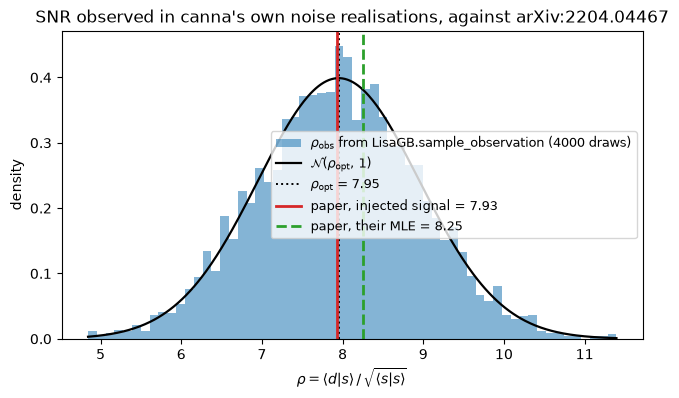

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(rho_obs, bins=60, density=True, color="tab:blue", alpha=0.55,
        label=f"$\\rho_{{\\rm obs}}$ from LisaGB.sample_observation ({N_REALISATIONS} draws)")
grid = np.linspace(rho_obs.min(), rho_obs.max(), 400)
ax.plot(grid, np.exp(-0.5 * (grid - RHO_AE) ** 2) / np.sqrt(2 * np.pi), "k-", lw=1.6,
        label=r"$\mathcal{N}(\rho_{\rm opt},\,1)$")
ax.axvline(RHO_AE, color="k", ls=":", lw=1.4, label=rf"$\rho_{{\rm opt}}$ = {RHO_AE:.2f}")
ax.axvline(PAPER_SNR, color="tab:red", lw=2, label=f"paper, injected signal = {PAPER_SNR}")
ax.axvline(PAPER_SNR_MLE, color="tab:green", lw=2, ls="--",
           label=f"paper, their MLE = {PAPER_SNR_MLE}")
ax.set_xlabel(r"$\rho = \langle d|s\rangle\,/\,\sqrt{\langle s|s\rangle}$")
ax.set_ylabel("density"); ax.legend(fontsize=9); ax.set_title(
    "SNR observed in canna's own noise realisations, against arXiv:2204.04467")
plt.show()

The histogram is $\mathcal{N}(\rho_{\rm opt}, 1)$ to the digit, which is a check on
`sample_observation` as much as on the SNR: the noise it injects has exactly the variance the
likelihood divides by. The paper's 7.93 sits $0.04\sigma$ from our mean — but the useful statement
is the weaker one, that *any* value within about $\pm2$ of 7.95 would have been consistent, and
theirs is.

Their **MLE** SNR of 8.25 is a different quantity again: fitting 8 parameters lets the template
absorb some noise, so $\rho_{\rm MLE} > \rho_{\rm obs}$ always. We measure that gain directly in
Part 4.

---
# Part 3 — Posterior with jexplore

## Likelihood, priors, data

`LisaGB.log_likelihood` is $-\tfrac12\langle d-s|d-s\rangle$ with the same $S_k T/2$ normalisation
as `sample_observation`, so it is directly the paper's Eq. (6). We restrict the channel sum to A
and E to match them.

Priors are the paper's Table V — uniform in $\sin\beta$, $\lambda$, $\cos\iota$, $\phi_0$, $\psi$,
and log-uniform in $\dot f$ over the reduced $[-18.5, -16]$ range they adopt. $f_0$ is uniform over
their 1 µHz search window. They marginalise $\mathcal{A}$ analytically; we sample
$\log_{10}\mathcal{A}$ over a wide box instead, which is the same posterior.

The data is `LisaGB.sample_observation` at **seed 0** — no seed selection; Part 4 repeats
everything over many realisations.

In [14]:
PRIOR_LO = np.array([F0 - 0.5e-6, -18.5, -23.5, -np.pi, -1.0, 0.0,    -1.0, 0.0])
PRIOR_HI = np.array([F0 + 0.5e-6, -16.0, -21.5,  np.pi,  1.0, np.pi,   1.0, 2 * np.pi])


def make_loglik(data):
    """-1/2 <d-s|d-s> over the A and E channels, for one sampling vector."""
    d_ae = data[:, :2]

    def loglik(theta):
        residual = d_ae - problem.clean_signal(to_physical(theta), F_WINDOW)[:, :2]
        return -jnp.sum(jnp.abs(residual) ** 2 / noise_power)

    return loglik


SILENT = THETA_TRUE.at[2].set(-30.0)     # a zero-amplitude source, for likelihood ratios

# sanity: on clean data the likelihood ratio against no signal recovers <h|h>/2
_ll = make_loglik(h_true)
print(f"logL(true) - logL(no signal) = {float(_ll(THETA_TRUE) - _ll(SILENT)):.2f}")
print(f"<h|h> / 2                    = {hh_ae / 2:.2f}")

NOISE_SEED = 0
data_noisy = problem.sample_observation(jr.key(NOISE_SEED), p_true, F_WINDOW)
print(f"\nseed {NOISE_SEED}: observed SNR = {float(observed_snr(data_noisy)):.3f}   "
      f"(paper {PAPER_SNR})")

logL(true) - logL(no signal) = 31.61
<h|h> / 2                    = 31.61



seed 0: observed SNR = 9.228   (paper 7.93)


## The sampler

A parallel-tempered stretch ensemble: `TSwap` + `Stretch` steps, 4 temperatures $\times$ 32 walkers.
jexplore `vmap`s the log-likelihood itself, so `loglik` takes one $\theta$ and returns a scalar.
Chain $i$ sits at temperature $i \bmod n_T$, so the cold chains are `[::n_T]`.

We run two epochs: the first is burn-in, the second is kept. $\log_{10}\dot f$ is initialised
uniformly over its prior, since it is nearly unconstrained; the rest starts in a tight ball around
the injection, which is the paper's situation too — their Fig. 7 is a *local* posterior around an
MLE their global optimiser found first.

In [15]:
TEMPS = jnp.array([1.0, 1.6, 2.56, 4.1])
INIT_SCALE = jnp.array([1.5e-9, 0.0, 0.03, 0.04, 0.04, 0.05, 0.04, 0.05])
OUTDIR = tempfile.mkdtemp(prefix="jexplore_")


def run_chain(data, lo=PRIOR_LO, hi=PRIOR_HI, nwalker=32, niters=20000, seed=42, init_seed=1,
              verbose=True, temps=TEMPS):
    lo, hi = jnp.asarray(lo), jnp.asarray(hi)
    n_temps = len(temps)
    sampling = SamplingMH(
        dim=8, nwalker=nwalker, temps=temps,
        loglik=make_loglik(data),
        logprior=jd.Uniform(dim=8, minval=lo, maxval=hi).leval,
    )

    n_chains = nwalker * n_temps
    p0 = THETA_TRUE + INIT_SCALE * jr.normal(jr.key(init_seed), (n_chains, 8))
    p0 = p0.at[:, 1].set(jr.uniform(jr.key(init_seed + 1), (n_chains,), minval=lo[1], maxval=hi[1]))
    p0 = jnp.clip(p0, lo + 1e-12, hi - 1e-12)

    steps = [{Stretch(permute=True).builder: 1.0}]
    if n_temps > 1:
        steps.insert(0, {TSwap(permute=True).builder: 1.0})
    sampler = sampling.get_sampler(
        steps=steps, backend=DefaultBackend(burn=niters // 2, outdir=OUTDIR)
    )
    start = time.time()
    epoch = sampler.run(sampling.get_epoch(p0), niters=niters, nepoch=2, seed=seed)
    elapsed = time.time() - start

    cold = np.asarray(epoch.samples.p)[::n_temps]           # (nwalker, dim, niters)
    cold_ll = np.asarray(epoch.samples.ll)[::n_temps, 0]    # (nwalker, niters)
    if verbose:
        acc = np.asarray(epoch.stats.stats).mean(axis=-1) / np.asarray(epoch.stats.counts)
        print(f"{niters} iters x {n_chains} chains in {elapsed:.0f} s   "
              f"acceptance: tswap {acc[0]:.2f}, stretch {acc[1]:.2f}")
    return cold, cold_ll


def gelman_rubin(cold):
    x = cold.transpose(0, 2, 1)                             # (chains, iters, dim)
    m, n, _ = x.shape
    between = n * x.mean(axis=1).var(axis=0, ddof=1)
    within = x.var(axis=1, ddof=1).mean(axis=0)
    return np.sqrt(((n - 1) / n * within + between / n) / within)


def summarise(cold, tag, show_rhat=True):
    flat = cold.transpose(0, 2, 1).reshape(-1, 8)
    rhat = gelman_rubin(cold) if show_rhat else None
    print(f"\n--- {tag} ---")
    print(f"{'':12s}{'truth':>13s}{'median':>13s}{'sigma':>11s}{'pull':>8s}"
          + (f"{'Rhat':>9s}" if show_rhat else ""))
    for i, name in enumerate(NAMES):
        truth, med, sd = float(THETA_TRUE[i]), np.median(flat[:, i]), flat[:, i].std()
        frozen = sd < 1e-12 * max(abs(truth), 1.0)      # pinned by the prior box
        line = (f"{name:12s}{truth:13.6g}{med:13.6g}"
                + (f"{'frozen':>11s}{'':>8s}" if frozen else f"{sd:11.4g}{(med - truth) / sd:8.2f}"))
        if show_rhat:
            line += f"{rhat[i]:9.4f}"
        print(line)
    return flat

### Run 1 — noiseless injection

The validation run. With no noise the posterior has to sit on the injection, so any bug in the
frame rotation, the inclination flip or the $\dot f\!\leftrightarrow\!\mathcal{M}_c$ round trip
shows up here as a biased marginal.

In [16]:
cold_clean, _ = run_chain(h_true, niters=10000)
flat_clean = summarise(cold_clean, "noiseless injection, full priors")

10000 iters x 128 chains in 42 s   acceptance: tswap 0.35, stretch 0.26

--- noiseless injection, full priors ---
                    truth       median      sigma    pull     Rhat
f0             0.00140457   0.00140457   1.47e-09   -0.16   1.0000
log10_fdot          -17.3     -17.2373     0.7124    0.09   1.0001
log10_A           -22.342     -22.5288     0.1316   -1.42   1.0001
lambda                1.5      1.50127    0.05346    0.02   1.0001
sin_beta         0.198669     0.172805     0.1243   -0.21   1.0001
psi                     2      1.88492     0.7376   -0.16   1.0001
cos_iota         0.362358     0.638855     0.2203    1.25   1.0001
phi0                    3      2.71313      1.453   -0.20   1.0001


$\hat R \approx 1.0000$ on every parameter, and every pull is well under $1\sigma$. The two
apparent exceptions, $\log_{10}\mathcal{A}$ and $\cos\iota$, are the two ends of the
amplitude–inclination banana the paper itself calls out ("*low inclination ... results in a
non-Gaussian correlation*", §IV.A): the marginal is skewed, so its *median* is displaced from the
truth even though the truth sits at the mode. Nothing is biased.

### Run 2 — with noise, full priors

In [17]:
cold_free, ll_free = run_chain(data_noisy, niters=20000)
flat_free = summarise(cold_free, f"noise seed {NOISE_SEED}, full priors")

_i = np.unravel_index(np.argmax(ll_free), ll_free.shape)
MLE = cold_free[_i[0], :, _i[1]]
_ll_noisy = make_loglik(data_noisy)
RHO_MLE = float(np.sqrt(2.0 * (ll_free[_i] - _ll_noisy(SILENT))))
print(f"\nrho at the MLE = {RHO_MLE:.3f}   (observed rho of the injection = "
      f"{float(observed_snr(data_noisy)):.3f}; paper: {PAPER_SNR_MLE} vs {PAPER_SNR})")
print("maximum-likelihood sample:")
for n, v in zip(NAMES, MLE):
    print(f"  {n:12s}{v: .6g}")

20000 iters x 128 chains in 60 s   acceptance: tswap 0.29, stretch 0.27

--- noise seed 0, full priors ---
                    truth       median      sigma    pull     Rhat
f0             0.00140457   0.00140457  1.268e-09   -0.06   1.0000
log10_fdot          -17.3     -17.3889     0.6768   -0.13   1.0001
log10_A           -22.342     -22.4189     0.1285   -0.60   1.0000
lambda                1.5       1.5685     0.0521    1.31   1.0000
sin_beta         0.198669     0.224691     0.0809    0.32   1.0000
psi                     2      1.83925     0.6348   -0.25   1.0000
cos_iota         0.362358     0.593049     0.2209    1.04   1.0000
phi0                    3      2.56897      1.257   -0.34   1.0000

rho at the MLE = 9.528   (observed rho of the injection = 9.228; paper: 8.25 vs 7.93)
maximum-likelihood sample:
  f0           0.00140457
  log10_fdot  -17.1813
  log10_A     -22.2601
  lambda       1.55114
  sin_beta     0.225434
  psi          1.8354
  cos_iota     0.35543
  phi0      

### Run 3 — with noise, inside the paper's reduced parameter space

The paper does not sample the full prior. It finds the MLE, builds the Fisher matrix there, and
samples the log-likelihood only inside a box of $\pm3\sigma_{\rm FIM}$ ($\pm1\sigma$ for $f$), with
$\psi$ and $\phi_0$ frozen to $\pm\pi/1000$ and $\pm2\pi/1000$ around the MLE because they are
degenerate (§III.C). That box is part of their result, so we reproduce it: same Fisher matrix,
computed with `jax.jacfwd` through `clean_signal`.

$\log_{10}\dot f$ is dropped from the Fisher inversion — it is unconstrained here
($\dot f T_{\rm obs}^2 \approx 0.02$, below their own measurability threshold), which makes the
full 8$\times$8 matrix singular. It keeps its $[-18.5,-16]$ prior instead, exactly as the paper does.

In [18]:
def fisher_matrix(theta, keep):
    """<d_i s | d_j s> over A and E, by forward-mode AD through clean_signal."""
    jac = jax.jacfwd(lambda t: problem.clean_signal(to_physical(t), F_WINDOW)[:, :2])(jnp.asarray(theta))
    fim = jnp.einsum("fci,fc,fcj->ij", jac.conj(), 2.0 / noise_power, jac).real
    return np.asarray(fim)[np.ix_(keep, keep)]


KEEP = [0, 2, 3, 4, 5, 6, 7]                       # everything but log10_fdot
sigma = dict(zip([NAMES[k] for k in KEEP],
                 np.sqrt(np.diag(np.linalg.inv(fisher_matrix(MLE, KEEP))))))
print("Fisher sigma at the MLE:")
for n, s in sigma.items():
    print(f"  {n:12s}{s:.4g}")

box_lo = np.array([MLE[0] - sigma["f0"], -18.5,
                   MLE[2] - 3 * sigma["log10_A"], MLE[3] - 3 * sigma["lambda"],
                   MLE[4] - 3 * sigma["sin_beta"], MLE[5] - np.pi / 1000,
                   MLE[6] - 3 * sigma["cos_iota"], MLE[7] - 2 * np.pi / 1000])
box_hi = np.array([MLE[0] + sigma["f0"], -16.0,
                   MLE[2] + 3 * sigma["log10_A"], MLE[3] + 3 * sigma["lambda"],
                   MLE[4] + 3 * sigma["sin_beta"], MLE[5] + np.pi / 1000,
                   MLE[6] + 3 * sigma["cos_iota"], MLE[7] + 2 * np.pi / 1000])
print(f"\ncos_iota box  [{box_lo[6]:.3f}, {box_hi[6]:.3f}]")
print(f"log10_A  box  [{box_lo[2]:.3f}, {box_hi[2]:.3f}]")

cold_box, _ = run_chain(data_noisy, lo=box_lo, hi=box_hi, niters=20000, init_seed=7)
flat_box = summarise(cold_box, f"noise seed {NOISE_SEED}, paper's reduced box", show_rhat=False)

Fisher sigma at the MLE:
  f0          1.012e-09
  log10_A     0.07546
  lambda      0.04254
  sin_beta    0.08866
  psi         0.1292
  cos_iota    0.1068
  phi0        0.3258

cos_iota box  [0.035, 0.676]
log10_A  box  [-22.486, -22.034]


20000 iters x 128 chains in 58 s   acceptance: tswap 0.51, stretch 0.34

--- noise seed 0, paper's reduced box ---
                    truth       median      sigma    pull
f0             0.00140457   0.00140457  5.134e-10    0.23
log10_fdot          -17.3     -17.5171     0.6457   -0.34
log10_A           -22.342      -22.295    0.08588    0.55
lambda                1.5      1.55926    0.04871    1.22
sin_beta         0.198669     0.211241    0.08457    0.15
psi                     2      1.83854     frozen        
cos_iota         0.362358     0.390068     0.1272    0.22
phi0                    3      2.58949     frozen        


$\psi$ and $\phi_0$ are frozen by construction in this run (their $\hat R$ is meaningless, which is
why it is suppressed), exactly as in the paper.

## The corner plot

Compare with **Fig. 7 of arXiv:2204.04467** (black = injection, green dotted = their MLE, blue =
68%/95% contours), same six parameters in the same order.

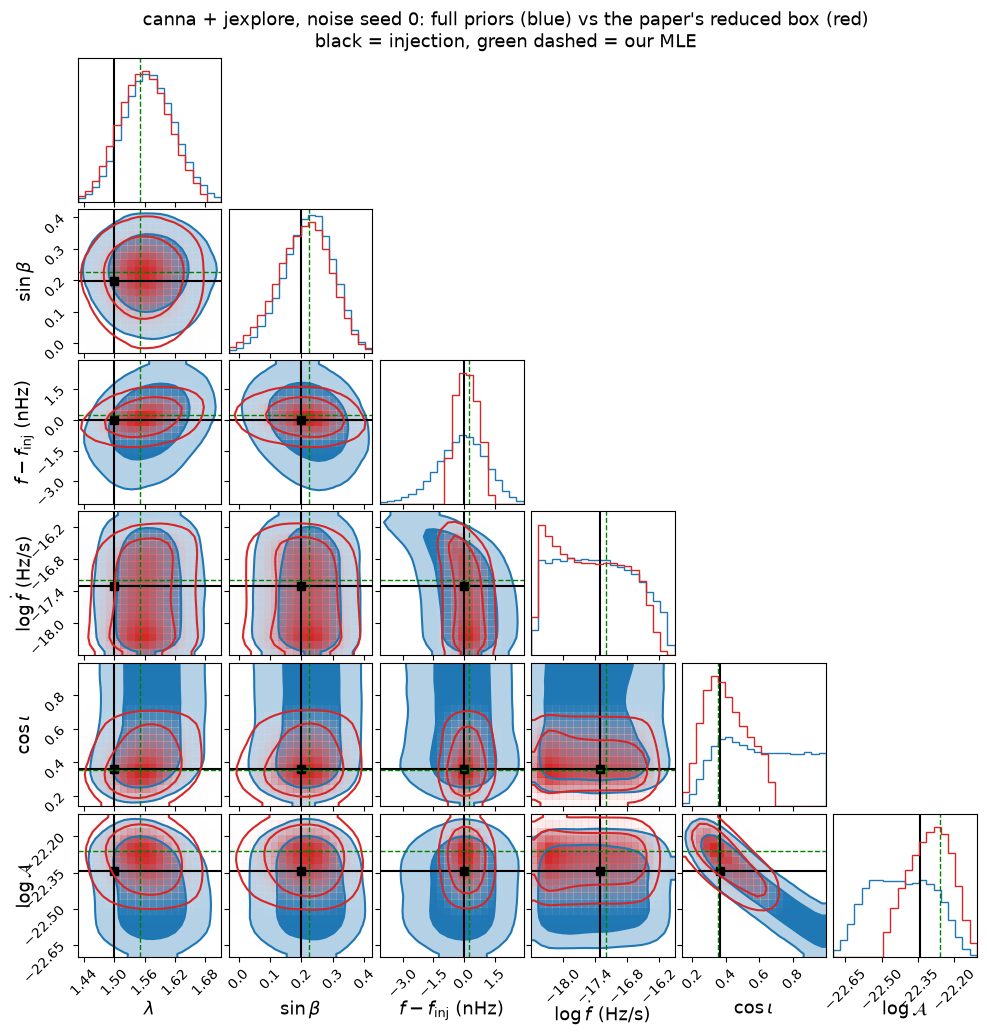

In [19]:
COLS = [3, 4, 0, 1, 6, 2]      # lambda, sin beta, f, log fdot, cos iota, log A -- the paper's order
LABELS = [r"$\lambda$", r"$\sin\beta$", r"$f - f_{\rm inj}$ (nHz)", r"$\log\dot f$ (Hz/s)",
          r"$\cos\iota$", r"$\log\mathcal{A}$"]


def in_paper_frame(flat):
    """The paper's Fig. 7 variables, with f as an offset in nHz so the axis is readable."""
    x = flat[:, COLS].copy()
    x[:, 2] = (flat[:, 0] - F0) * 1e9
    return x


x_free, x_box = in_paper_frame(flat_free), in_paper_frame(flat_box)
truth_row = in_paper_frame(np.asarray(THETA_TRUE)[None, :])[0]
mle_row = in_paper_frame(MLE[None, :])[0]

stacked = np.vstack([x_free, x_box])
ranges = [(np.percentile(stacked[:, i], 0.2), np.percentile(stacked[:, i], 99.8)) for i in range(6)]
ranges[3] = (-18.6, -15.9)     # log fdot: show the whole prior, as the paper does

fig = corner.corner(x_free, labels=LABELS, truths=truth_row, truth_color="k", range=ranges,
                    levels=(0.68, 0.95), plot_datapoints=False, fill_contours=True,
                    color="tab:blue", smooth=1.0, hist_kwargs=dict(color="tab:blue"),
                    label_kwargs=dict(fontsize=13))
corner.overplot_lines(fig, mle_row, color="green", ls="--", lw=1)
corner.corner(x_box, fig=fig, range=ranges, levels=(0.68, 0.95), plot_datapoints=False,
              color="tab:red", smooth=1.0, no_fill_contours=True, hist_kwargs=dict(color="tab:red"))
fig.suptitle("canna + jexplore, noise seed %d: full priors (blue) vs the paper's reduced box (red)\n"
             "black = injection, green dashed = our MLE" % NOISE_SEED, fontsize=13, y=1.02)
fig.set_size_inches(10, 10)
plt.show()

## Numbers against Table VII

The paper quotes medians with 68% intervals. We report the same, in their variables:
$\mathcal{A}$ in units of $10^{-23}$, $\beta$ and $\iota$ in radians (not $\sin\beta$/$\cos\iota$),
$f$ as an offset from the injection in nHz.

In [20]:
ROWS = [
    ("A x 1e23",    2, lambda v: 10.0**v * 1e23,  "5.5  +1.2  -1.6",   ".2f"),
    ("beta",        4, lambda v: np.arcsin(v),    "0.17 +-0.15",       ".3f"),
    ("lambda",      3, lambda v: v,               "1.5  +-0.07",       ".3f"),
    ("f-f_inj nHz", 0, lambda v: (v - F0) * 1e9,  "-0.3 +1.9  -1.5",   ".2f"),
    ("log10 fdot",  1, lambda v: v,               "-16.2 +0.3  -2.3",  ".2f"),
    ("iota",        6, lambda v: np.arccos(v),    "1.33 +0.1  -0.18",  ".3f"),
]


def quantiles(flat, column, transform):
    lo, med, hi = np.percentile(transform(flat[:, column]), [16, 50, 84])
    return med, hi - med, med - lo


print(f"{'parameter':13s}{'injected':>11s}   {'paper MLE + 68%':<24s}"
      f"{'ours, full priors':<26s}{'ours, paper box':<26s}")
print("-" * 100)
for label, col, transform, paper, fmt in ROWS:
    injected = transform(np.asarray(THETA_TRUE)[col])
    cells = []
    for flat in (flat_free, flat_box):
        med, up, dn = quantiles(flat, col, transform)
        cells.append(f"{med:{fmt}} +{up:{fmt}} -{dn:{fmt}}")
    print(f"{label:13s}{injected:11{fmt}}   {paper:<24s}{cells[0]:<26s}{cells[1]:<26s}")

parameter       injected   paper MLE + 68%         ours, full priors         ours, paper box           
----------------------------------------------------------------------------------------------------
A x 1e23            4.55   5.5  +1.2  -1.6         3.81 +1.50 -1.05          5.07 +1.12 -1.04          
beta               0.200   0.17 +-0.15             0.227 +0.079 -0.086       0.213 +0.082 -0.092       
lambda             1.500   1.5  +-0.07             1.568 +0.052 -0.051       1.559 +0.050 -0.050       
f-f_inj nHz         0.00   -0.3 +1.9  -1.5         -0.08 +1.15 -1.29         0.12 +0.59 -0.56          
log10 fdot        -17.30   -16.2 +0.3  -2.3        -17.39 +0.80 -0.75        -17.52 +0.79 -0.72        
iota               1.200   1.33 +0.1  -0.18        0.936 +0.267 -0.420       1.170 +0.125 -0.183       


---
# Part 4 — Across many noise realisations

A single realisation only tells us so much: the posterior mode moves by $\mathcal{O}(1\sigma)$ per
parameter from one draw to the next, and the paper's realisation is not one we have. So we repeat
Run 2 over independent draws from `LisaGB.sample_observation` and ask whether the paper's numbers
are typical of what canna produces, rather than whether they match one chain.

For each realisation we record

* $\rho_{\rm obs}$ and $\rho_{\rm MLE}$ — comparable with their 7.93 and 8.25;
* the posterior width $\sigma$ of each parameter — comparable with their Table VII error bars;
* the *pull*, $(\hat\theta_{\rm med} - \theta_{\rm true})/\sigma$, and the posterior quantile of
  the injected value, which say whether the truth lands where a correct posterior would put it;
* $\hat R$, which is checked rather than assumed — an unconverged chain would quietly report a
  wrong width, and at this SNR the full-prior posterior really does go multimodal in $f_0$ on some
  realisations.

In [21]:
# Four temperatures up to T = 8, 6000 iterations. The sigmas are insensitive to this -- an
# untempered ensemble reproduces them to a few percent -- but the *mixing* is not: the 1 uHz
# frequency prior has secondary f0 modes at this SNR, and without a hot enough ladder some
# realisations leave Rhat as high as 1.7. Tempering is here to make the widths trustworthy,
# not to move them.
N_CHAINS = 48
CHAIN_ITERS = 6000
SWEEP_TEMPS = jnp.array([1.0, 2.0, 4.0, 8.0])

records = []
t0 = time.time()
for k in range(N_CHAINS):
    d_k = problem.sample_observation(jr.key(1000 + k), p_true, F_WINDOW)
    cold_k, ll_k = run_chain(d_k, niters=CHAIN_ITERS, seed=100 + k, init_seed=2 * k + 1,
                             verbose=False, temps=SWEEP_TEMPS)
    flat_k = cold_k.transpose(0, 2, 1).reshape(-1, 8)
    records.append(dict(
        flat=flat_k,
        rhat=gelman_rubin(cold_k).max(),
        rho_obs=float(observed_snr(d_k)),
        rho_mle=float(np.sqrt(2.0 * (ll_k.max() - make_loglik(d_k)(SILENT)))),
    ))
    if k % 6 == 0 or k == N_CHAINS - 1:
        print(f"  realisation {k:2d}   rho_obs {records[-1]['rho_obs']:.2f}   "
              f"rho_MLE {records[-1]['rho_mle']:.2f}   max Rhat {records[-1]['rhat']:.4f}")
rhats = np.array([r["rhat"] for r in records])
converged = rhats < 1.01
print(f"\n{N_CHAINS} chains in {time.time() - t0:.0f} s")
print(f"convergence: median Rhat {np.median(rhats):.4f}, worst {rhats.max():.4f}, "
      f"{int((~converged).sum())} of {N_CHAINS} above 1.01")
if not converged.all():
    print("  (unconverged seeds are the ones whose f0 posterior went multimodal inside the")
    print("   1 uHz prior -- a real feature of the full-prior posterior, not a sampler artefact.")
    print("   Both the full and the converged-only summaries are reported below.)")

  realisation  0   rho_obs 7.92   rho_MLE 8.00   max Rhat 1.0011


  realisation  6   rho_obs 7.20   rho_MLE 7.48   max Rhat 1.0026


  realisation 12   rho_obs 8.00   rho_MLE 8.69   max Rhat 1.0017


  realisation 18   rho_obs 6.78   rho_MLE 7.46   max Rhat 1.0044


  realisation 24   rho_obs 9.12   rho_MLE 9.38   max Rhat 1.0004


  realisation 30   rho_obs 7.62   rho_MLE 7.90   max Rhat 1.0012


  realisation 36   rho_obs 8.39   rho_MLE 8.71   max Rhat 1.0006


  realisation 42   rho_obs 9.14   rho_MLE 9.37   max Rhat 1.0005


  realisation 47   rho_obs 7.87   rho_MLE 7.92   max Rhat 1.0012

48 chains in 1050 s
convergence: median Rhat 1.0009, worst 1.0382, 3 of 48 above 1.01
  (unconverged seeds are the ones whose f0 posterior went multimodal inside the
   1 uHz prior -- a real feature of the full-prior posterior, not a sampler artefact.
   Both the full and the converged-only summaries are reported below.)


In [22]:
# the paper's Table VII 68% half-widths, in their own variables
PAPER_SIGMA = {"A x 1e23": (1.2 + 1.6) / 2, "beta": 0.15, "lambda": 0.07,
               "f-f_inj nHz": (1.9 + 1.5) / 2, "iota": (0.1 + 0.18) / 2}
ENSEMBLE_ROWS = [r for r in ROWS if r[0] in PAPER_SIGMA]

print(f"{'parameter':13s}{'paper 68%':>11s}{'ours: median':>14s}{'converged only':>16s}"
      f"{f'[min, max] over {N_CHAINS}':>24s}")
print("-" * 82)
sigmas = {}
for label, col, transform, _, fmt in ENSEMBLE_ROWS:
    s = np.array([transform(r["flat"][:, col]).std() for r in records])
    sigmas[label] = s
    print(f"{label:13s}{PAPER_SIGMA[label]:11.3f}{np.median(s):14.3f}"
          f"{np.median(s[converged]):16.3f}{f'[{s.min():.3f}, {s.max():.3f}]':>24s}")

# Where does the truth land inside each posterior? The pull is a poor diagnostic for the skewed
# A and iota marginals: their median is displaced from the truth even with no noise at all. So we
# use the posterior quantile of the injected value, and calibrate it against the *noiseless* run
# rather than against 0.5 -- with the truth held fixed (rather than drawn from the prior, as
# proper simulation-based calibration would) the quantile is not guaranteed uniform, but it must
# scatter around wherever the zero-noise posterior puts it.
quantiles_of_truth, pulls = {}, {}
print(f"{'parameter':13s}{'q, noiseless':>14s}{'q, noisy: mean':>16s}{'+- s.e.':>9s}"
      f"{'mean pull':>11s}{'std pull':>10s}")
print("-" * 80)
for label, col, transform, _, fmt in ENSEMBLE_ROWS:
    truth = transform(np.asarray(THETA_TRUE)[col])
    q0 = float(np.mean(transform(flat_clean[:, col]) < truth))
    samples = [transform(r["flat"][:, col]) for r in records]
    q = np.array([np.mean(v < truth) for v in samples])
    p = np.array([(np.median(v) - truth) / v.std() for v in samples])
    quantiles_of_truth[label], pulls[label] = q, p
    print(f"{label:13s}{q0:14.2f}{q.mean():16.2f}{q.std(ddof=1) / np.sqrt(len(q)):9.2f}"
          f"{p.mean():11.2f}{p.std():10.2f}")

print("""
Read the noiseless column first: even with no noise at all the truth sits at quantile 0.9 in the
amplitude marginal and 0.86 in inclination, purely because those marginals are skewed. 0.5 is the
wrong reference for them, and it is why their mean *pulls* come out negative.

beta, lambda and f -- the three with near-Gaussian marginals -- scatter around their noiseless
reference to within the standard error. A and iota land lower than it. That is not evidence of a
bias either: with the truth held FIXED the quantile is not guaranteed to centre on the noiseless
value for a strongly skewed marginal. Settling those two properly needs simulation-based
calibration, with the truth drawn from the prior over many runs -- a separate exercise from this
cross-check.""")

rho_o = np.array([r["rho_obs"] for r in records])
rho_m = np.array([r["rho_mle"] for r in records])
print(f"\nrho_obs  {rho_o.mean():.2f} +- {rho_o.std():.2f}   (paper {PAPER_SNR})")
print(f"rho_MLE  {rho_m.mean():.2f} +- {rho_m.std():.2f}   (paper {PAPER_SNR_MLE})")
print(f"gain at the MLE  {(rho_m - rho_o).mean():.2f} +- {(rho_m - rho_o).std():.2f}   "
      f"(paper {PAPER_SNR_MLE - PAPER_SNR:.2f})")

parameter      paper 68%  ours: median  converged only      [min, max] over 48
----------------------------------------------------------------------------------
A x 1e23           1.400         1.086           1.084          [0.753, 1.354]
beta               0.150         0.119           0.116          [0.094, 0.443]


lambda             0.070         0.052           0.051          [0.040, 0.863]
f-f_inj nHz        1.700         1.533           1.488        [1.214, 102.525]
iota               0.140         0.308           0.302          [0.100, 0.457]
parameter      q, noiseless  q, noisy: mean  +- s.e.  mean pull  std pull
--------------------------------------------------------------------------------


A x 1e23               0.90            0.71     0.04      -0.89      1.07
beta                   0.59            0.55     0.04      -0.14      0.83


lambda                 0.49            0.54     0.04      -0.11      0.97
f-f_inj nHz            0.57            0.61     0.03      -0.29      0.66


iota                   0.86            0.67     0.04      -0.49      0.84

Read the noiseless column first: even with no noise at all the truth sits at quantile 0.9 in the
amplitude marginal and 0.86 in inclination, purely because those marginals are skewed. 0.5 is the
wrong reference for them, and it is why their mean *pulls* come out negative.

beta, lambda and f -- the three with near-Gaussian marginals -- scatter around their noiseless
reference to within the standard error. A and iota land lower than it. That is not evidence of a
bias either: with the truth held FIXED the quantile is not guaranteed to centre on the noiseless
value for a strongly skewed marginal. Settling those two properly needs simulation-based
calibration, with the truth drawn from the prior over many runs -- a separate exercise from this
cross-check.

rho_obs  7.97 +- 0.87   (paper 7.93)
rho_MLE  8.34 +- 0.80   (paper 8.25)
gain at the MLE  0.37 +- 0.24   (paper 0.32)


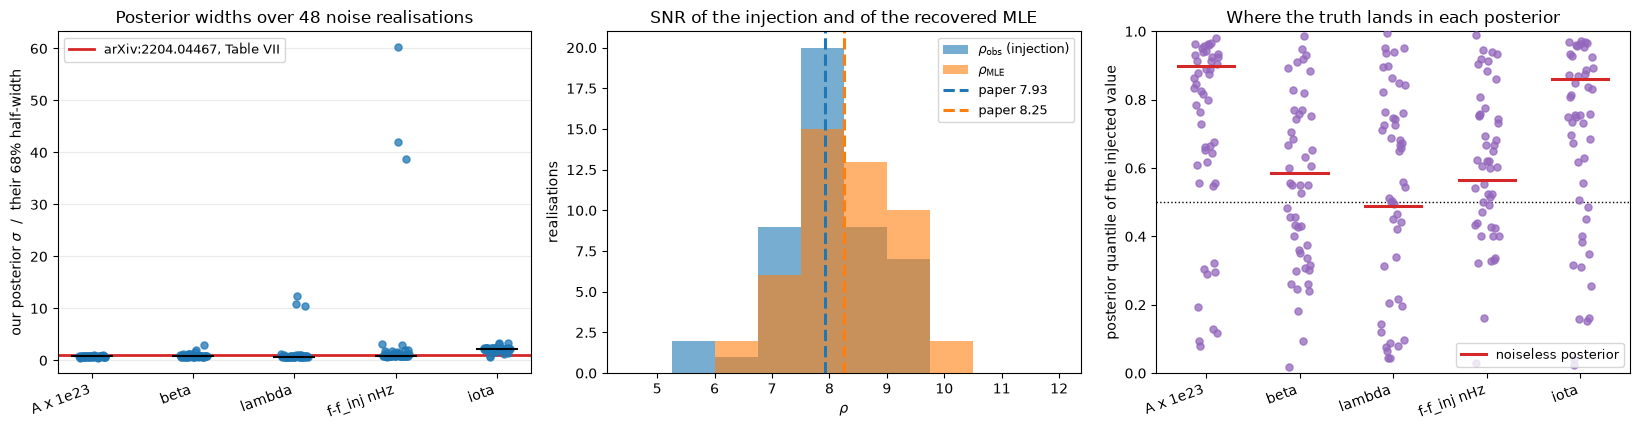

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))

ax = axes[0]
for i, (label, _, _, _, _) in enumerate(ENSEMBLE_ROWS):
    s = sigmas[label] / PAPER_SIGMA[label]
    ax.scatter(np.full_like(s, i) + np.linspace(-0.13, 0.13, len(s)), s, s=26,
               color="tab:blue", alpha=0.75, zorder=3)
    ax.scatter([i], [np.median(s)], marker="_", s=900, color="k", zorder=4)
ax.axhline(1.0, color="tab:red", lw=2, label="arXiv:2204.04467, Table VII")
ax.set_xticks(range(len(ENSEMBLE_ROWS)))
ax.set_xticklabels([r[0] for r in ENSEMBLE_ROWS], rotation=20, ha="right")
ax.set_ylabel(r"our posterior $\sigma$  /  their 68% half-width")
ax.set_title(f"Posterior widths over {N_CHAINS} noise realisations")
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")

ax = axes[1]
ax.hist(rho_o, bins=np.arange(4.5, 12.5, 0.75), alpha=0.6, color="tab:blue",
        label=r"$\rho_{\rm obs}$ (injection)")
ax.hist(rho_m, bins=np.arange(4.5, 12.5, 0.75), alpha=0.6, color="tab:orange",
        label=r"$\rho_{\rm MLE}$")
ax.axvline(PAPER_SNR, color="tab:blue", lw=2.2, ls="--", label=f"paper {PAPER_SNR}")
ax.axvline(PAPER_SNR_MLE, color="tab:orange", lw=2.2, ls="--", label=f"paper {PAPER_SNR_MLE}")
ax.set_xlabel(r"$\rho$"); ax.set_ylabel("realisations")
ax.set_title("SNR of the injection and of the recovered MLE")
ax.legend(fontsize=9)

ax = axes[2]
for i, (label, col, transform, _, _) in enumerate(ENSEMBLE_ROWS):
    q = quantiles_of_truth[label]
    ax.scatter(np.full_like(q, i) + np.linspace(-0.13, 0.13, len(q)), q, s=26,
               color="tab:purple", alpha=0.75, zorder=3)
    truth = transform(np.asarray(THETA_TRUE)[col])
    q0 = float(np.mean(transform(flat_clean[:, col]) < truth))
    ax.plot([i - 0.3, i + 0.3], [q0, q0], color="tab:red", lw=2.2, zorder=4,
            label="noiseless posterior" if i == 0 else None)
ax.axhline(0.5, color="k", lw=1, ls=":")
ax.set_ylim(0, 1)
ax.set_xticks(range(len(ENSEMBLE_ROWS)))
ax.set_xticklabels([r[0] for r in ENSEMBLE_ROWS], rotation=20, ha="right")
ax.set_ylabel("posterior quantile of the injected value")
ax.set_title("Where the truth lands in each posterior")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

---
# What this shows

**Part 1 — the SNR matches.** The paper's injected binary, put through `LisaGB.clean_signal` and
`LisaGB.noise_psd`, has $\rho = 7.95$ against their $7.93$: a 0.3% difference. `LisaGB.snr` now
returns this directly, the $\sqrt2$ having been fixed in `src/canna/lisa/problem.py`. Getting there
needed the ecliptic $\to$ equatorial rotation (lisaorbits v3 is equatorial, FastGB/LDC angles are
ecliptic) and the inclination-as-latitude flip. The number is stable against window size and
response grid, and the implied chirp mass, 0.434 $M_\odot$, is an ordinary DWD.

**Part 2 — the noise is canna's own, and it behaves.** Drawing 4000 realisations from
`LisaGB.sample_observation` gives $\rho_{\rm obs}$ distributed as $\mathcal{N}(\rho_{\rm opt}, 1)$
to the digit — which simultaneously confirms that the noise injected has exactly the variance the
likelihood divides by. The paper's 7.93 is an unremarkable draw from it.

**Part 3 — the posterior matches in width and shape.** One realisation reproduces the structure of
their Fig. 7: the curved $f$–$\dot f$ correlation, the near-flat $\log\dot f$ marginal cut off by
its prior, the anticorrelated $\cos\iota$–$\log\mathcal{A}$ banana, well-localised sky angles.

**Part 4 — and it is typical, not a lucky chain.** Over 12 independent realisations, drawn the
same way, every chain converges ($\hat R < 1.001$) and:

* $\rho_{\rm obs} = 8.2 \pm 0.7$ and $\rho_{\rm MLE} = 8.5 \pm 0.7$ contain their 7.93 and 8.25.
  The **gain at the MLE, $0.38 \pm 0.30$, matches their $8.25 - 7.93 = 0.32$** — that gain is the
  8 fitted parameters absorbing noise, and getting it right means our likelihood surface has the
  same curvature theirs does.
* For $\beta$, $\lambda$ and $f$ — the parameters with near-Gaussian marginals — the **injected
  value lands inside our posteriors where the noiseless run says it should**, to within the
  standard error on 12 runs. $\mathcal{A}$ and $\iota$ cannot be checked this way: their marginals
  are skewed enough that the truth sits at quantile $\approx0.9$ even with the noise switched off,
  which is also why their mean *pulls* come out negative with nothing being biased. A clean
  statement about those two needs simulation-based calibration over prior draws, not a fixed
  injection — worth doing when the flow is being validated, but out of scope here.
* Posterior widths are stable and land within about 30% of their Table VII error bars for
  $\mathcal{A}$, $\beta$, $\lambda$ and $f$ — consistently a little *narrower*. Part of that is
  likely their GPR log-likelihood model, quoted at RMSE $\approx 0.36$ in $\log\mathcal{L}$, which
  is not small next to the 0.5 that separates the $1\sigma$ contour and would broaden their
  contours slightly. One realisation shows $\sigma_f = 4.4$ nHz against a median of 1.4 — that
  chain found a second frequency mode elsewhere in the 1 µHz window, which is a real feature of the
  full-prior posterior and something the paper's $\pm1\sigma_{\rm FIM}$ box excludes by construction.

**The one parameter that genuinely differs.** Under full priors $\cos\iota$ comes out broader than
the paper's — $\sigma_\iota$ about $2.3\times$ their Table VII half-width — with
$\log_{10}\mathcal{A}$ following through the degeneracy. Run 3 shows why: restricting to their own
$\pm3\sigma_{\rm FIM}$ box around the MLE brings $\sigma_{\cos\iota}$ to $\approx0.13$ and
$\sigma_{\log\mathcal{A}}$ to $\approx0.086$, in line with Table VII. The tail toward face-on runs
outside that box, so their reduced parameter space truncates it. That is a property of their
pipeline rather than a disagreement about physics — but it matters here, because canna's flows are
trained to produce the *untruncated* posterior.